In [1]:
import wikipedia
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import requests
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "llama3"


In [3]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
def get_embedding(text):
    """Generate embedding for a given text using the sentence transformer model."""
    return embedding_model.encode(text)

In [4]:
def run_model(prompt):
    """Query the local Ollama model and return the response and latency."""
    start_time = time.time()
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "options": {
            "num_predict": 60
        }
    }
    try:
        response = requests.post(OLLAMA_URL, json=payload)
        response.raise_for_status()
        result = response.json()
        output_text = result.get("response", "")
    except Exception as e:
        print(f"Error querying Ollama: {e}")
        output_text = ""
    latency = time.time() - start_time
    return output_text, latency


In [5]:
def semantic_similarity(model_output, reference):
    """Compute cosine similarity between model output and reference text."""
    emb1 = get_embedding(model_output)
    emb2 = get_embedding(reference)
    similarity = cosine_similarity([emb1], [emb2])[0][0]
    return float(similarity)

def evidence_score(response):
    """Compare model response with a Wikipedia summary of the first sentence."""
    try:
        query = response.split(".")[0]
        wiki_text = wikipedia.summary(query, sentences=2)
        emb1 = get_embedding(response)
        emb2 = get_embedding(wiki_text)
        score = cosine_similarity([emb1], [emb2])[0][0]
        return float(score)
    except Exception:
        # Wikipedia lookup failed or other error, return neutral score
        return 0.5

In [6]:
def self_consistency(outputs):
    """Compute average pairwise similarity among multiple outputs for the same prompt."""
    embeddings = [get_embedding(o) for o in outputs]
    sims = []
    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
            sims.append(sim)
    if not sims:
        return 1.0
    return float(np.mean(sims))


In [7]:
def evaluate_prompt(prompt, reference):
    """Run three generations for a prompt and compute all metrics."""
    outputs = []
    latencies = []
    for _ in range(3):
        response, latency = run_model(prompt)
        outputs.append(response)
        latencies.append(latency)
    main_output = outputs[0]
    sim_score = semantic_similarity(main_output, reference)
    evidence = evidence_score(main_output)
    consistency = self_consistency(outputs)
    avg_latency = np.mean(latencies)
    final_score = (
        0.4 * sim_score +
        0.4 * evidence +
        0.2 * consistency
    )
    return {
        "response": main_output,
        "similarity": sim_score,
        "evidence": evidence,
        "consistency": consistency,
        "latency": avg_latency,
        "final": final_score
    }

In [10]:
dataset = [

# -------- Geography --------
{"prompt":"What is the capital of Japan?","reference":"Tokyo"},
{"prompt":"What is the capital of France?","reference":"Paris"},
{"prompt":"What is the capital of Canada?","reference":"Ottawa"},
{"prompt":"What is the capital of Australia?","reference":"Canberra"},
{"prompt":"What is the capital of Germany?","reference":"Berlin"},
{"prompt":"Which is the largest country by area?","reference":"Russia"},
{"prompt":"Which ocean is the largest?","reference":"Pacific Ocean"},
{"prompt":"Which desert is the largest hot desert?","reference":"Sahara Desert"},
{"prompt":"Which river is the longest in the world?","reference":"Nile River"},
{"prompt":"Mount Everest lies in which mountain range?","reference":"Himalayas"},
{"prompt":"Which country has the largest population?","reference":"China"},
{"prompt":"Which continent is the Sahara Desert located in?","reference":"Africa"},

# -------- Mathematics --------
{"prompt":"What is 12 multiplied by 8?","reference":"96"},
{"prompt":"What is the square root of 144?","reference":"12"},
{"prompt":"Solve for x: 2x + 6 = 14","reference":"x = 4"},
{"prompt":"What is 15 percent of 200?","reference":"30"},
{"prompt":"What is the value of pi approximately?","reference":"3.1416"},
{"prompt":"What is the cube of 5?","reference":"125"},
{"prompt":"What is 7 squared?","reference":"49"},
{"prompt":"What is the derivative of x^2?","reference":"2x"},
{"prompt":"What is the integral of 1/x?","reference":"ln(x)"},
{"prompt":"What is 100 divided by 4?","reference":"25"},

# -------- Science --------
{"prompt":"What gas do humans breathe out?","reference":"Carbon dioxide"},
{"prompt":"What is the chemical symbol for water?","reference":"H2O"},
{"prompt":"What planet is known as the Red Planet?","reference":"Mars"},
{"prompt":"What is the speed of light approximately?","reference":"299792458 meters per second"},
{"prompt":"What force pulls objects toward Earth?","reference":"Gravity"},
{"prompt":"What part of the cell contains genetic material?","reference":"Nucleus"},
{"prompt":"What gas do plants absorb from the atmosphere?","reference":"Carbon dioxide"},
{"prompt":"What is the boiling point of water at sea level?","reference":"100 degrees Celsius"},
{"prompt":"What is the freezing point of water?","reference":"0 degrees Celsius"},
{"prompt":"Which organ pumps blood in the human body?","reference":"Heart"},
{"prompt":"Which planet is the largest in the solar system?","reference":"Jupiter"},
{"prompt":"Which particle carries a negative charge?","reference":"Electron"},

# -------- History --------
{"prompt":"Who wrote Romeo and Juliet?","reference":"William Shakespeare"},
{"prompt":"Who was the first President of the United States?","reference":"George Washington"},
{"prompt":"In which year did World War II end?","reference":"1945"},
{"prompt":"Who discovered penicillin?","reference":"Alexander Fleming"},
{"prompt":"Who painted the Mona Lisa?","reference":"Leonardo da Vinci"},
{"prompt":"Which ancient civilization built the pyramids?","reference":"Ancient Egyptians"},
{"prompt":"Who was known as the Maid of Orleans?","reference":"Joan of Arc"},
{"prompt":"Who invented the telephone?","reference":"Alexander Graham Bell"},
{"prompt":"Who was the first man to walk on the Moon?","reference":"Neil Armstrong"},
{"prompt":"Which empire was ruled by Julius Caesar?","reference":"Roman Empire"},

# -------- Technology --------
{"prompt":"Who founded Microsoft?","reference":"Bill Gates"},
{"prompt":"What does CPU stand for?","reference":"Central Processing Unit"},
{"prompt":"What does HTTP stand for?","reference":"Hypertext Transfer Protocol"},
{"prompt":"What programming language is commonly used for machine learning?","reference":"Python"},
{"prompt":"Who founded Tesla?","reference":"Elon Musk"},
{"prompt":"What does RAM stand for?","reference":"Random Access Memory"},
{"prompt":"Which company developed the iPhone?","reference":"Apple"},
{"prompt":"What does GPU stand for?","reference":"Graphics Processing Unit"},
{"prompt":"Which language is used for styling web pages?","reference":"CSS"},
{"prompt":"Which protocol secures web communication?","reference":"HTTPS"},

# -------- Reasoning --------
{"prompt":"If a car travels 60 km per hour for 3 hours how far does it travel?","reference":"180 km"},
{"prompt":"If you have 10 apples and give away 4 how many remain?","reference":"6"},
{"prompt":"If a triangle has angles 90, 45 and 45 what type is it?","reference":"Right triangle"},
{"prompt":"If 5 machines make 5 parts in 5 minutes how long for 100 machines to make 100 parts?","reference":"5 minutes"},
{"prompt":"If today is Monday what day will it be in 3 days?","reference":"Thursday"},
{"prompt":"If a rectangle has length 10 and width 5 what is the area?","reference":"50"},
{"prompt":"If a train travels 50 km in 1 hour how far in 4 hours?","reference":"200 km"},
{"prompt":"If the perimeter of a square is 20 what is its side length?","reference":"5"},
{"prompt":"If you double 8 what do you get?","reference":"16"},
{"prompt":"If a dozen eggs cost 12 dollars what is the price per egg?","reference":"1 dollar"},

# -------- Conceptual --------
{"prompt":"What is photosynthesis?","reference":"Process by which plants convert sunlight into chemical energy"},
{"prompt":"What is gravity?","reference":"Force that attracts objects with mass toward each other"},
{"prompt":"What is machine learning?","reference":"Field of AI where computers learn patterns from data"},
{"prompt":"What is artificial intelligence?","reference":"Simulation of human intelligence in machines"},
{"prompt":"What is a black hole?","reference":"Region of spacetime with gravity so strong that nothing escapes"},
{"prompt":"What is DNA?","reference":"Molecule carrying genetic information"},
{"prompt":"What is an algorithm?","reference":"Step by step procedure to solve a problem"},
{"prompt":"What is cloud computing?","reference":"Delivery of computing services over the internet"},
{"prompt":"What is the internet?","reference":"Global network of interconnected computers"},
{"prompt":"What is blockchain?","reference":"Distributed ledger technology for secure transactions"},

# -------- Hallucination traps --------
{"prompt":"Who was the president of the United States in 1785?","reference":"There was no US president in 1785"},
{"prompt":"What is the capital of the fictional country Wakanda?","reference":"Wakanda is fictional"},
{"prompt":"Who invented the electric spoon in 1889?","reference":"No known inventor"},
{"prompt":"What is the capital city of Atlantis?","reference":"Atlantis is mythical"},
{"prompt":"Who discovered the planet Vulcan in 1915?","reference":"Planet Vulcan does not exist"},
{"prompt":"Which scientist discovered gravity in 1805?","reference":"Gravity was not discovered in 1805"},
{"prompt":"What year was the invisible city of Eloria founded?","reference":"Eloria is fictional"},
{"prompt":"Who wrote the book Shadows of Jupiter in 1750?","reference":"No such book exists"},
{"prompt":"Which country owns the Moon?","reference":"No country owns the Moon"},
{"prompt":"Which company invented teleportation technology?","reference":"Teleportation technology does not exist"},

# -------- Unanswerable --------
{"prompt":"What is the exact number of stars in the universe?","reference":"Unknown"},
{"prompt":"How many grains of sand exist on Earth?","reference":"Unknown"},
{"prompt":"What will be the population of Earth in 3000?","reference":"Unknown"},
{"prompt":"Which person will live the longest in the future?","reference":"Unknown"},
{"prompt":"When will humans colonize another galaxy?","reference":"Unknown"},
{"prompt":"What is the exact number of trees on Earth right now?","reference":"Unknown"},
{"prompt":"Which language will dominate the world in 500 years?","reference":"Unknown"},
{"prompt":"Which company will be the richest in 2100?","reference":"Unknown"},
{"prompt":"Which city will be the largest in 2200?","reference":"Unknown"},
{"prompt":"What technology will replace the internet?","reference":"Unknown"}

]

In [12]:
records = []
for i, item in enumerate(dataset):
    prompt = item["prompt"]
    reference = item["reference"]
    print(f"Running prompt {i+1}/{len(dataset)}: {prompt}")
    result = evaluate_prompt(prompt, reference)
    records.append({
        "Prompt": prompt,
        "Reference": reference,
        "Model_Response": result["response"],
        "Similarity": result["similarity"],
        "Evidence": result["evidence"],
        "Consistency": result["consistency"],
        "Latency": round(result["latency"], 3),
        "Final_Score": round(result["final"], 3)
    })

df = pd.DataFrame(records)
print("\nEvaluation Results:")
print(df)


Running prompt 1/94: What is the capital of Japan?
Running prompt 2/94: What is the capital of France?
Running prompt 3/94: What is the capital of Canada?
Running prompt 4/94: What is the capital of Australia?
Running prompt 5/94: What is the capital of Germany?
Running prompt 6/94: Which is the largest country by area?
Running prompt 7/94: Which ocean is the largest?
Running prompt 8/94: Which desert is the largest hot desert?
Running prompt 9/94: Which river is the longest in the world?
Running prompt 10/94: Mount Everest lies in which mountain range?
Running prompt 11/94: Which country has the largest population?
Running prompt 12/94: Which continent is the Sahara Desert located in?
Running prompt 13/94: What is 12 multiplied by 8?
Running prompt 14/94: What is the square root of 144?
Running prompt 15/94: Solve for x: 2x + 6 = 14
Running prompt 16/94: What is 15 percent of 200?
Running prompt 17/94: What is the value of pi approximately?
Running prompt 18/94: What is the cube of 5?

In [13]:
summary = df[["Similarity","Evidence","Consistency","Final_Score","Latency"]].mean()

summary

Similarity     0.475107
Evidence       0.517707
Consistency    0.919729
Final_Score    0.581053
Latency        5.435723
dtype: float64

In [14]:
import numpy as np

scores = df["Final_Score"]

mean = scores.mean()
std = scores.std()

ci = 1.96 * (std / np.sqrt(len(scores)))

print("Reliability Score:", mean)
print("Confidence Interval:", ci)

Reliability Score: 0.5810531914893617
Confidence Interval: 0.030294618726081062


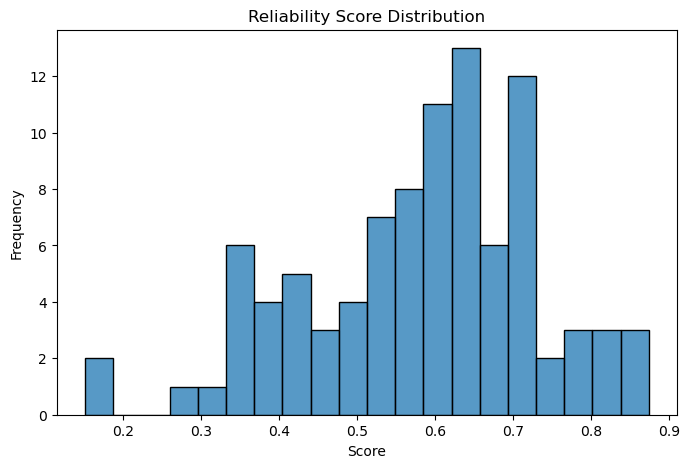

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Final_Score"], bins=20)

plt.title("Reliability Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

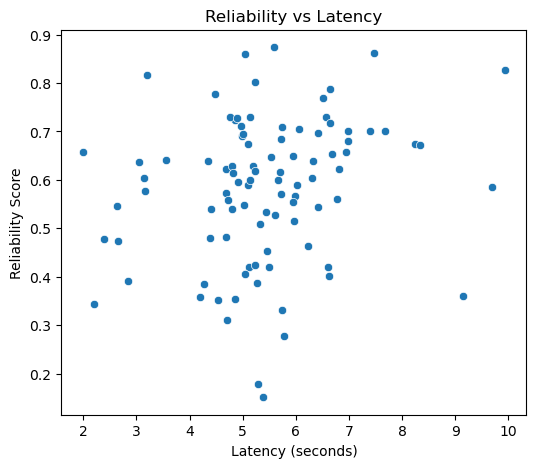

In [16]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=df["Latency"],
    y=df["Final_Score"]
)

plt.xlabel("Latency (seconds)")
plt.ylabel("Reliability Score")
plt.title("Reliability vs Latency")

plt.show()

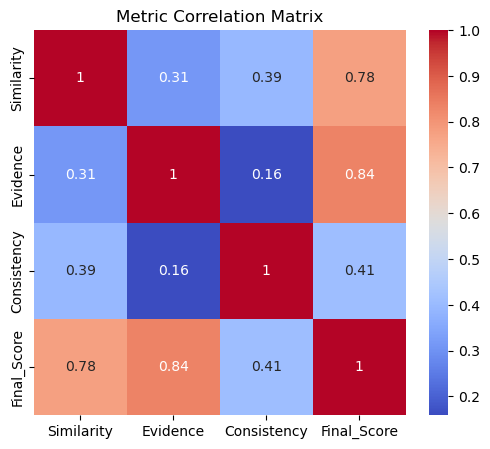

In [17]:
corr = df[["Similarity","Evidence","Consistency","Final_Score"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Metric Correlation Matrix")

plt.show()

In [18]:
df.sort_values("Final_Score", ascending=False).head(10)

,Prompt,Reference,Model_Response,Similarity,Evidence,Consistency,Latency,Final_Score
3,What is the capital of Australia?,Canberra,The capital of Australia is Canberra.,0.816601,0.869126,1.000000,5.598,0.874
2,What is the capital of Canada?,Ottawa,The capital of Canada is Ottawa.,0.770211,0.887007,1.000000,7.462,0.863
64,What is photosynthesis?,Process by which plants convert sunlight into ...,"Photosynthesis is the process by which plants,...",0.781025,0.894464,0.941556,5.040,0.859
0,What is the capital of Japan?,Tokyo,The capital of Japan is Tokyo ().,0.700754,0.870981,0.987078,9.941,0.826
4,What is the capital of Germany?,Berlin,The capital of Germany is Berlin.,0.757105,0.785900,1.000000,3.193,0.817
1,What is the capital of France?,Paris,The capital of France is Paris.,0.725336,0.781851,1.000000,5.234,0.803
7,Which desert is the largest hot desert?,Sahara Desert,The largest hot desert in the world is the Sah...,0.629743,0.857818,0.960370,6.639,0.787
9,Mount Everest lies in which mountain range?,Himalayas,"Mount Everest, also known as Chomolungma or Sa...",0.662475,0.839904,0.879827,4.484,0.777
35,Who was the first President of the United States?,George Washington,The first President of the United States was G...,0.544692,0.879858,0.996524,6.519,0.769
32,Which planet is the largest in the solar system?,Jupiter,The largest planet in our solar system is Jupi...,0.510603,0.852825,0.925021,4.770,0.730


In [19]:
df.sort_values("Final_Score").head(10)

,Prompt,Reference,Model_Response,Similarity,Evidence,Consistency,Latency,Final_Score
89,What is the exact number of trees on Earth rig...,Unknown,"A great question! Unfortunately, it's challeng...",-0.008701,-0.078572,0.931168,5.385,0.151
84,What is the exact number of stars in the unive...,Unknown,A question that has puzzled humans for centuri...,0.029244,0.008583,0.821569,5.292,0.179
61,If the perimeter of a square is 20 what is its...,5,That's an easy one!\n\nSince a square has four...,0.197503,0.098092,0.791865,5.775,0.277
15,What is 15 percent of 200?,30,"To find 15% of 200, you can multiply 200 by 0....",0.248664,0.036911,0.985862,4.697,0.311
88,When will humans colonize another galaxy?,Unknown,What a fascinating question! Colonizing anothe...,0.019582,0.500000,0.623217,5.747,0.332
62,If you double 8 what do you get?,16,"If you double 8, you would get... (drumroll pl...",0.467184,-0.076965,0.933254,2.200,0.343
55,If you have 10 apples and give away 4 how many...,6,Easy one!\n\nYou start with 10 apples and give...,0.430507,-0.023016,0.945555,4.529,0.352
63,If a dozen eggs cost 12 dollars what is the pr...,1 dollar,That's an easy one!\n\nSince there are 12 eggs...,0.299693,0.104009,0.955283,4.853,0.353
92,Which city will be the largest in 2200?,Unknown,What a great question!\n\nPredicting the futur...,0.080807,0.500000,0.625945,4.195,0.358
59,If a rectangle has length 10 and width 5 what ...,50,The formula for the area of a rectangle is:\n\...,0.187512,0.272316,0.878729,9.148,0.360


In [20]:
!pip install streamlit

In [21]:
df.to_csv("llama3_results.csv", index=False)